## Quantum Reservoir Computing — NARMA Benchmark

This notebook benchmarks Quantum Reservoir Computing (QRC) on the **NARMA** (Non-linear Auto-Regressive Moving Average) task family, a standard testbed for temporal machine learning.

**Why NARMA?** NARMA is designed to require both non-linear processing and multi-step memory: it cannot be solved by any linear model. The NARMA-\(p\) order controls the memory depth required — \(p=2\) needs short memory, \(p=15\) needs long memory. Comparing circuit families on NARMA isolates the reservoir's temporal processing capability from its static expressivity.

**Connection to the project**: Experiment 2 of the project plan uses NARMA-5 with Fourier \(s_k\) encoding as the QRC task to study how \(R_{\mathrm{eff}}\) and \(\Lambda\) co-determine performance. This notebook extends that to a full family sweep and visualises the resulting performance landscapes.

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import metrics
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import warnings; warnings.filterwarnings('ignore')

#from technical_analysis_indicators import get_regressor_vars
from QRC import  QuantumRC_Circuit
import os
from tqdm import tqdm

## Toy Example — Single NARMA Run

A single QRC instance on NARMA-15 demonstrates the full pipeline:
1. **Generate NARMA data**: \(y(k) = 0.3\,y(k-1) + 0.05\,y(k-1)\sum_{i=1}^{p}y(k-i) + 1.5\,u(k)\,u(k-p) + 0.1\)
2. **Encode** each input \(u(k)\) into the reservoir via Fourier \(s_k\) encoding.
3. **Run** the quantum reservoir circuit and collect observable expectations.
4. **Train** a Ridge readout on the training split.
5. **Evaluate** MSE on the test split and plot predictions vs true values.

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler


def generate_narma_fourier_task(
    T=2000, n_train=1400, narma_order=5,
    n_a=6, seed=0, normalize=True, use_g = True
):
    """
    NARMA-n task with Fourier-rich external input.
    
    The input to the QRC is u_t ∈ [0, 2π] (uniform random).
    The driver s_t = g(u_t) where g has frequencies matching the
    exponential encoding's budget for n_a qubits.
    The target y_{t+1} follows NARMA dynamics in s_t and past y.
    
    Parameters
    ----------
    T : int
        Total length of the time series.
    n_train : int
        Length of training set.
    narma_order : int
        NARMA memory depth. 5 is standard; 10 tests longer memory.
    n_a : int
        Encoding qubit count — determines g's frequency content.
    """
    rng = np.random.default_rng(seed)
    K = (3 ** n_a - 1) // 2  # 364 for n_a=6
    
    # Random Fourier coefficients for g
    a = rng.uniform(-1, 1, size=K + 1)
    b = rng.uniform(-1, 1, size=K + 1)
    
    def g(u):
        """Fourier-rich driver function: g: [0, 2π] → R, with frequencies up to K."""
        u = np.atleast_1d(u)
        out = np.zeros_like(u, dtype=float)
        for k in range(K + 1):
            out += a[k] * np.cos(k * u) + b[k] * np.sin(k * u)
        return out
    
    
    # Normalize g to [0, 0.5] (NARMA expects s_t ∈ [0, 0.5])
    u_probe = np.linspace(0, 2 * np.pi, 5000)
    g_vals = g(u_probe) if use_g else u_probe
    g_min, g_max = g_vals.min(), g_vals.max()
    
    def g_normalized(u):
        if use_g:
            return 0.5 * (g(u) - g_min) / (g_max - g_min)
        return 0.5 * (u - g_min) / (g_max - g_min)
    
    # Generate input sequence u_t and driver s_t
    u = rng.uniform(0, 2 * np.pi, size=T)
    s = g_normalized(u)
    
    # Run NARMA dynamics: need narma_order burn-in steps
    y = np.zeros(T)
    n = narma_order
    for t in range(n - 1, T - 1):
        y[t + 1] = (0.3 * y[t] 
                    + 0.05 * y[t] * np.mean(y[t - n + 1:t + 1]) #np.sum
                    + 1.5 * s[t - n + 1] * s[t] 
                    + 0.1)
    
    # Drop burn-in
    u = u[n:]
    y = y[n:]
    T_eff = len(y)
    assert n_train < T_eff
    
    # QRC input: u_t (the reservoir sees u_t and must predict y_{t+1})
    # Target: y itself
    u = u.reshape(-1, 1)
    y = y.reshape(-1, 1)
    u_train, u_test = u[:n_train], u[n_train:]
    y_train, y_test = y[:n_train], y[n_train:]
    
    scaler = None
    if normalize:
        # Scale the INPUT u to [0, 1] so the QRC encoding sees a standard range
        u_scaler = MinMaxScaler(feature_range=(0, 1))
        u_train = u_scaler.fit_transform(u_train)
        u_test = u_scaler.transform(u_test)
        # Scale the target separately
        y_scaler = MinMaxScaler(feature_range=(0, 1))
        y_train = y_scaler.fit_transform(y_train)
        y_test = y_scaler.transform(y_test)
        scaler = (u_scaler, y_scaler)
    
    return {
        'u_train': u_train, 'u_test': u_test,   # QRC inputs
        'y_train': y_train, 'y_test': y_test,   # targets
        'g': g_normalized,
        'K': K,
        'narma_order': narma_order,
        'scaler': scaler,
    }

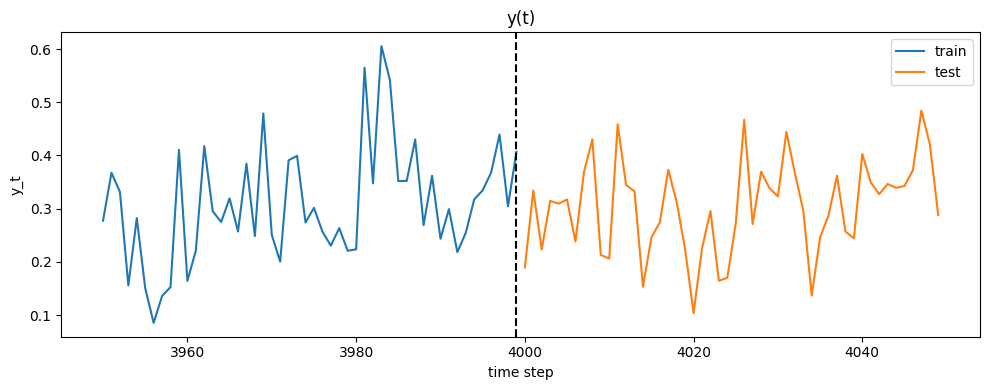

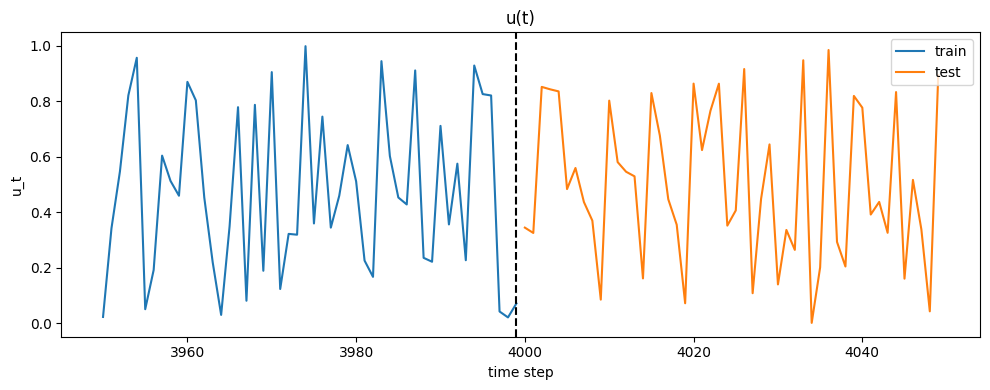

In [55]:
data = generate_narma_fourier_task(T=5000, n_train=4000, narma_order=15, n_a=3)
u_train, y_train = data['u_train'], data['y_train']
u_test, y_test = data['u_test'], data['y_test']
t_train = np.arange(len(y_train))
t_test = np.arange(len(y_train), len(y_train) + len(y_test))

plt.figure(figsize=(10, 4))
plt.plot(t_train[-50:], y_train[-50:], label="train")
plt.plot(t_test[:50], y_test[:50], label="test")
plt.axvline(t_train[-1], linestyle="--", color='black')
plt.xlabel("time step")
plt.ylabel("y_t")
plt.title("y(t)")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t_train[-50:], u_train[-50:], label="train")
plt.plot(t_test[:50], u_test[:50], label="test")
plt.axvline(t_train[-1], linestyle="--", color='black')
plt.xlabel("time step")
plt.ylabel("u_t")
plt.title("u(t)")
plt.legend()
plt.tight_layout()
plt.show()



In [56]:
from qiskit.quantum_info import SparsePauliOp
# ── Random Pauli observables ─────────────────────────────────────
def random_pauli_observables(n_obs, n_qubits, seed=42):
    rng = np.random.default_rng(seed)
    paulis = np.array(['I', 'X', 'Y', 'Z'])
    return [SparsePauliOp(''.join(rng.choice(paulis, size=n_qubits)))
            for _ in range(n_obs)]

all_obs_sine = random_pauli_observables(1500, 6, seed=42)

In [57]:
qrc_exp = QuantumRC_Circuit(
    nqbits=3, input_mode='exogenous', dim_s=1, dim_y=1, gates_set='Haar', 
    encoding='exponential', k_exp=3, theta_scale=2*np.pi, n_measure=6,
    observables_type=[1,2,3],
    alpha=1e-10,
)

qrc_exp.train(s=data['u_train'], y=data['y_train'])
y_pred_exp = qrc_exp.test(s = data['u_test'], y=data['y_test'], retrain = True)
mse_exp = np.mean((y_pred_exp - data['y_test'])**2)


qrc_pauli = QuantumRC_Circuit(
    nqbits=3, input_mode='exogenous', dim_s=1, dim_y=1,gates_set='Haar',
    encoding='pauli', k_exp=3, theta_scale=2*np.pi, n_measure=6,
    observables_type=[1,2,3],
    alpha=1e-10,
)

qrc_pauli.train(s=data['u_train'], y=data['y_train'])
y_pred_pauli = qrc_pauli.test(s = data['u_test'], y=data['y_test'], retrain = True)
mse_pauli = np.mean((y_pred_pauli - data['y_test'])**2)

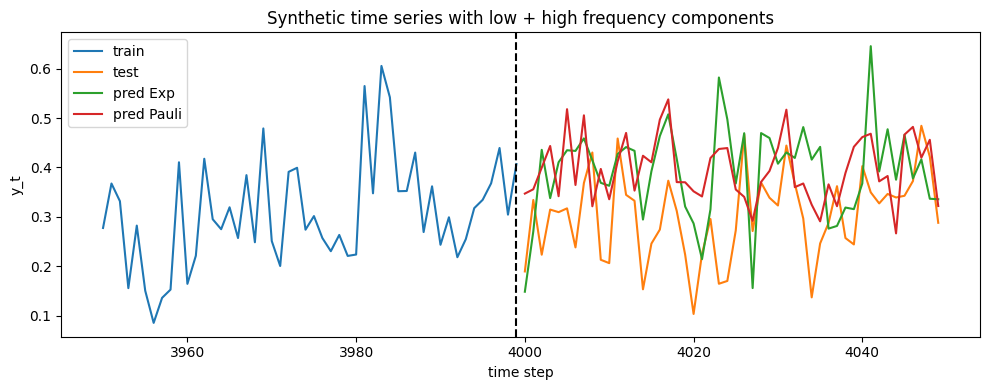

Test MSE Exponential:  0.01578327288722344 Test MSE Pauli:  0.020183289308794438


In [58]:
plt.figure(figsize=(10, 4))
plt.plot(t_train[-50:], y_train[-50:], label="train")
plt.plot(t_test[:50], y_test[:50], label="test")
plt.plot(t_test[:50], y_pred_exp[:50], label="pred Exp")
plt.plot(t_test[:50], y_pred_pauli[:50], label="pred Pauli")
plt.axvline(t_train[-1], linestyle="--", color='black')
plt.xlabel("time step")
plt.ylabel("y_t")
plt.title("Synthetic time series with low + high frequency components")
plt.legend()
plt.tight_layout()
plt.show()
print('Test MSE Exponential: ', mse_exp, 'Test MSE Pauli: ', mse_pauli)

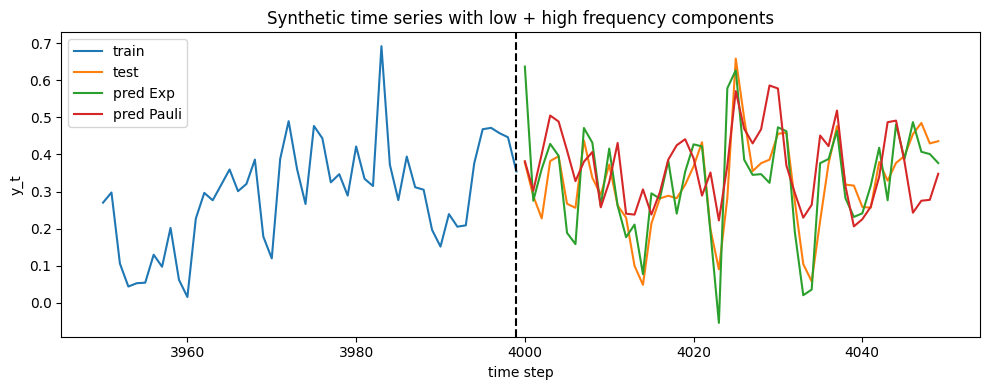

Test MSE Exponential:  0.00806049189281052 Test MSE Pauli:  0.022209064821183795


In [10]:
plt.figure(figsize=(10, 4))
plt.plot(t_train[-50:], y_train[-50:], label="train")
plt.plot(t_test[:50], y_test[:50], label="test")
plt.plot(t_test[:50], y_pred_exp[:50], label="pred Exp")
plt.plot(t_test[:50], y_pred_pauli[:50], label="pred Pauli")
plt.axvline(t_train[-1], linestyle="--", color='black')
plt.xlabel("time step")
plt.ylabel("y_t")
plt.title("Synthetic time series with low + high frequency components")
plt.legend()
plt.tight_layout()
plt.show()
print('Test MSE Exponential: ', mse_exp, 'Test MSE Pauli: ', mse_pauli)

In [6]:
qrc_exp = QuantumRC_Circuit(
    nqbits=3, input_mode='exogenous', dim_s=1, dim_y=1, gates_set='D2_random_XZY', degree = 6,
    encoding='exponential', k_exp=3, theta_scale=2*np.pi, n_measure=6,
    observables_type=[1,2,3],
    alpha=1e-10,
)

qrc_exp.train(s=data['u_train'], y=data['y_train'])
y_pred_exp = qrc_exp.test(s = data['u_test'], y=data['y_test'], retrain = True)
mse_exp = np.mean((y_pred_exp - data['y_test'])**2)

print('Test MSE Exponential D2_random_XZY: ', mse_exp)

Test MSE Exponential D2_random_XZY:  0.007192095667098362


In [7]:
qrc_exp = QuantumRC_Circuit(
    nqbits=3, input_mode='exogenous', dim_s=1, dim_y=1, gates_set='D2_random_XZ', degree = 6,
    encoding='exponential', k_exp=3, theta_scale=2*np.pi, n_measure=6,
    observables_type=[1,2,3],
    alpha=1e-10,
)

qrc_exp.train(s=data['u_train'], y=data['y_train'])
y_pred_exp = qrc_exp.test(s = data['u_test'], y=data['y_test'], retrain = True)
mse_exp = np.mean((y_pred_exp - data['y_test'])**2)

print('Test MSE Exponential D2_random_XZ: ', mse_exp)

Test MSE Exponential D2_random_XZ:  0.01462724800243234


## Systematic Family Sweep

We run `ns=100` independent QRC instances per configuration to estimate mean MSE and its standard deviation. Families swept:

- **G1, G2, G3** — gate-based random circuits, swept over number of gates \(n_g \in [10, 1000]\).
- **D2_random, D2_random_XZ, D2_random_XZY** — IQP-style, swept over expected degree \(\bar{d} \in [1, 14]\).
- **Scrambling ansatz** — \(K \times L\) grid (\(K \in [1,6]\), \(L \in [1,10]\)).
- **Haar** — ideal random unitary, single evaluation (upper bound).

Results are cached per (family, parameter, qubit-size) tuple in `results/NARMA/`.

In [13]:
# ── Gate-family comparison experiment ────────────────────────────────────────
import os
import numpy as np
from tqdm import tqdm

QRC_DIR = os.path.join("results", "time_series", "NARMA")
os.makedirs(QRC_DIR, exist_ok=True)


# ── Persistence helpers ───────────────────────────────────────────────────────
def _qrc_path(gates_name, nqbits, ns, num_gates=None, degree=None,
              n_layers=None, scrambler_depth=None):
    tag = gates_name
    if num_gates       is not None: tag += f"_ng{num_gates}"
    if degree          is not None: tag += f"_deg{float(degree)}"
    if n_layers        is not None: tag += f"_L{n_layers}"
    if scrambler_depth is not None: tag += f"_K{scrambler_depth}"
    return os.path.join(QRC_DIR, f"{tag}_{nqbits}q_{ns}runs.npz")


def _load_qrc(path):
    """Load a saved QRC NARMA experiment.

    Returns a dict with the same keys produced by run_narma_experiment.
    """
    d = np.load(path, allow_pickle=True)
    return {
        'mse_p':      d['mse_p'],
        'mse_e':      d['mse_e'],
        'y_pred_p':   d['y_pred_p'],
        'y_pred_e':   d['y_pred_e'],
        'ors':        d['ors'],
        'delta_s':    d['delta_s'],
        'var_x_p':    d['var_x_p'],
        'var_x_e':    d['var_x_e'],
        'X_train_p':  d['X_train_p'],
        'X_test_p':   d['X_test_p'],
        'X_train_e':  d['X_train_e'],
        'X_test_e':   d['X_test_e'],
    }


def _save_qrc(path, res):
    """Save the dict returned by run_narma_experiment.

    Pass the result dict directly:
        res = run_narma_experiment(...)
        _save_qrc(path, res)
    """
    np.savez_compressed(
        path,
        mse_p=np.asarray(res['mse_p']),
        mse_e=np.asarray(res['mse_e']),
        y_pred_p=np.asarray(res['y_pred_p']),
        y_pred_e=np.asarray(res['y_pred_e']),
        ors=np.asarray(res['ors']),
        delta_s=np.asarray(res['delta_s']),
        var_x_p=np.asarray(res['var_x_p']),
        var_x_e=np.asarray(res['var_x_e']),
        X_train_p=np.asarray(res['X_train_p']),
        X_test_p=np.asarray(res['X_test_p']),
        X_train_e=np.asarray(res['X_train_e']),
        X_test_e=np.asarray(res['X_test_e']),
    )
    print(f"  Saved → {path}")

In [14]:
from sklearn.linear_model import Ridge
from tqdm import tqdm
import numpy as np
from metrics import lorentz_curves, order_statistics_score, renyi2_entropy


def run_narma_experiment(
    gates_name,
    data,
    n_obs_list,
    ns=10,
    nqbits=3,
    k_exp=3,
    theta_scale=2*np.pi,
    n_measure=6,
    alpha=1e-10,
    # Mode controls
    input_mode='exogenous',      # 'exogenous' | 'autoregressive' | 'hybrid'
    feedback='teacher',          # 'teacher' | 'closed_loop'
    dim_s=1,
    dim_y=1,
    # Complexity-metric config
    nshots_ors=2000,
    K_ors=None,
    n_shadows=200,
    subsystem_size=2,
    t_dismiss=0,                  # washout steps to exclude from var_x
    # Training options
    retrain_on_test=False,
    verbose=False,
    **circuit_kwargs,
):
    """
    NARMA analogue of run_sine_experiment for QuantumRC_Circuit.

    Single-pass (fast) when the reservoir trajectory is independent of the
    readout (exogenous OR teacher-forced); rebuilds per n_obs otherwise.
    """
    s_train = data.get('u_train')
    s_test  = data.get('u_test')
    y_train = data['y_train']
    y_test  = data['y_test']
    n_test = y_test.shape[0]
    max_n_obs = n_obs_list[-1]
    if K_ors is None:
        K_ors = 2**nqbits

    single_pass = (input_mode == 'exogenous') or (feedback == 'teacher')

    # ── Result containers ────────────────────────────────────────────────
    mse_p = np.zeros((ns, len(n_obs_list)))
    mse_e = np.zeros((ns, len(n_obs_list)))
    yp_all = np.zeros((ns, len(n_obs_list), n_test))
    ye_all = np.zeros((ns, len(n_obs_list), n_test))
    ors_list, delta_s_list = [], []
    var_x_p_list, var_x_e_list = [], []
    # Keep only the last run's feature matrices (for sanity checks/plotting)
    Xp_tr_last = Xp_te_last = Xe_tr_last = Xe_te_last = None

    def _make_qrc(encoding, seed, n_obs=None):
        np.random.seed(seed)
        qrc = QuantumRC_Circuit(
            nqbits=nqbits, gates_set=gates_name, encoding=encoding,
            k_exp=k_exp, theta_scale=theta_scale, n_measure=n_measure,
            observables_type=[1, 2, 3], alpha=alpha,
            input_mode=input_mode, feedback=feedback,
            dim_s=dim_s, dim_y=dim_y,
            **circuit_kwargs,
        )
        trunc_to = max_n_obs if single_pass else n_obs
        qrc.observables = qrc.observables[:trunc_to]
        qrc.obs_array = np.array([o.to_matrix() for o in qrc.observables])
        return qrc

    def _call_train(qrc, cache=False):
        if input_mode == 'autoregressive':
            return qrc.train(y=y_train, cache_dm_traj=cache)
        return qrc.train(s=s_train, y=y_train, cache_dm_traj=cache)

    def _call_test(qrc, cache=False):
        kwargs = dict(retrain=retrain_on_test, cache_dm_traj=cache)
        if input_mode == 'autoregressive':
            return qrc.test(y=y_test, **kwargs)
        return qrc.test(s=s_test, y=y_test, **kwargs)

    def _project(dm_traj, obs):
        f = np.tensordot(obs, dm_traj, axes=[[2, 1], [1, 2]]).real
        return f.T[:-1]

    def _fit_and_predict(X_tr, y_tr, X_te, y_te, retrain):
        lm = Ridge(alpha=alpha).fit(X_tr, y_tr)
        preds, X_aug, y_aug = [], X_tr.copy(), y_tr.copy()
        for i in range(X_te.shape[0]):
            row = X_te[i:i+1]
            preds.append(lm.predict(row).ravel())
            if retrain:
                X_aug = np.vstack([X_aug, row])
                y_aug = np.vstack([y_aug, y_te[i].reshape(1, -1)])
                lm = Ridge(alpha=alpha).fit(X_aug, y_aug)
        return np.array(preds).ravel()

    desc = f"NARMA [{gates_name}] {input_mode}/{feedback}"
    for run in tqdm(range(ns), desc=desc):
        seed = run * 2

        if single_pass:
            qrc_p = _make_qrc('pauli', seed)
            qrc_e = _make_qrc('exponential', seed)

            _call_train(qrc_p, cache=True); dm_p_tr = qrc_p.dm_traj
            _call_test(qrc_p,  cache=True); dm_p_te = qrc_p.dm_traj
            _call_train(qrc_e, cache=True); dm_e_tr = qrc_e.dm_traj
            _call_test(qrc_e,  cache=True); dm_e_te = qrc_e.dm_traj

            full_obs = qrc_p.obs_array
            Xp_tr = _project(dm_p_tr, full_obs)
            Xp_te = _project(dm_p_te, full_obs)
            Xe_tr = _project(dm_e_tr, full_obs)
            Xe_te = _project(dm_e_te, full_obs)

            # Complexity metrics (reservoir-only; same for both encodings)
            _, sp, _ = lorentz_curves(
                qrc_p.get_reservoir, qrc_p.n_total, nshots_ors, 1, verbose=False)
            ors_list.append(
                order_statistics_score(sp, D=2**qrc_p.n_total, K=K_ors))
            _, delta_s_val, _ = renyi2_entropy(
                qrc_p.get_reservoir, qrc_p.n_total, n_shadows, 1,
                subsystem_size=subsystem_size, use_statevector=True, verbose=False)
            delta_s_list.append(delta_s_val)

            # Input sensitivity per encoding: variance over time
            # (excluding washout transient if specified)
            var_x_p_list.append(np.std(Xp_tr[t_dismiss:], axis=0))
            var_x_e_list.append(np.std(Xe_tr[t_dismiss:], axis=0))

            # Sweep n_obs
            for i, n_obs in enumerate(n_obs_list):
                yp = _fit_and_predict(Xp_tr[:, :n_obs], y_train,
                                      Xp_te[:, :n_obs], y_test, retrain_on_test)
                ye = _fit_and_predict(Xe_tr[:, :n_obs], y_train,
                                      Xe_te[:, :n_obs], y_test, retrain_on_test)
                yp_all[run, i] = yp;  ye_all[run, i] = ye
                mse_p[run, i] = np.mean((yp - y_test.ravel())**2)
                mse_e[run, i] = np.mean((ye - y_test.ravel())**2)
                if verbose:
                    print(f"  run={run} n_obs={n_obs:3d}  "
                          f"pauli={mse_p[run,i]:.4e}  exp={mse_e[run,i]:.4e}")

            # Save last run's feature matrices for inspection
            Xp_tr_last, Xp_te_last = Xp_tr, Xp_te
            Xe_tr_last, Xe_te_last = Xe_tr, Xe_te

        else:
            # Closed-loop: rebuild per n_obs
            qrc_ref = _make_qrc('pauli', seed, n_obs=max_n_obs)
            _, sp, _ = lorentz_curves(
                qrc_ref.get_reservoir, qrc_ref.n_total, nshots_ors, 1, verbose=False)
            ors_list.append(
                order_statistics_score(sp, D=2**qrc_ref.n_total, K=K_ors))
            _, delta_s_val, _ = renyi2_entropy(
                qrc_ref.get_reservoir, qrc_ref.n_total, n_shadows, 1,
                subsystem_size=subsystem_size, use_statevector=True, verbose=False)
            delta_s_list.append(delta_s_val)
            _call_train(qrc_ref)
            # In closed-loop we only have one trajectory available cheaply (Pauli ref)
            var_x_p_list.append(np.std(qrc_ref.X_train[t_dismiss:], axis=0))
            var_x_e_list.append(np.full_like(var_x_p_list[-1], np.nan))

            for i, n_obs in enumerate(n_obs_list):
                qrc_p = _make_qrc('pauli', seed, n_obs=n_obs)
                qrc_e = _make_qrc('exponential', seed, n_obs=n_obs)
                _call_train(qrc_p); yp = _call_test(qrc_p).ravel()
                _call_train(qrc_e); ye = _call_test(qrc_e).ravel()
                yp_all[run, i] = yp; ye_all[run, i] = ye
                mse_p[run, i] = np.mean((yp - y_test.ravel())**2)
                mse_e[run, i] = np.mean((ye - y_test.ravel())**2)
                if verbose:
                    print(f"  run={run} n_obs={n_obs:3d}  "
                          f"pauli={mse_p[run,i]:.4e}  exp={mse_e[run,i]:.4e}")

    # Stack var_x lists; rows of unequal length only happen if reservoirs differ,
    # which they don't here (same nqbits/n_measure across runs)
    return {
        'mse_p': mse_p, 'mse_e': mse_e,
        'y_pred_p': yp_all, 'y_pred_e': ye_all,
        'ors': np.array(ors_list),
        'delta_s': np.array(delta_s_list),
        'var_x_p': np.array(var_x_p_list),
        'var_x_e': np.array(var_x_e_list),
        'X_train_p': Xp_tr_last, 'X_test_p': Xp_te_last,
        'X_train_e': Xe_tr_last, 'X_test_e': Xe_te_last,
    }

In [15]:
# ── Config ─────────────────────────────────────────────────────────────────────────────
nqbits    = 3            # qubits / Fourier parameter (matches existing experiment above)
ns     = 100          # random reservoir instances per config
k_exp = 3
alpha = 1e-10
n_shadows = 5000
nshots_ors = 2000
K_ors = 4
n_obs_list  = np.arange(10, 1000, 50)   # sweep: number of observables
max_n_obs   = int(n_obs_list.max())    # 750
LOAD_QRC = True                                          # set False to recompute


In [16]:
# ── Haar baseline ─────────────────────────────────────────────────────────────
path = _qrc_path("Haar", nqbits, ns)
if LOAD_QRC and os.path.exists(path):
    print(f"Loading Haar  ← {path}")
    res = _load_qrc(path)
else:
    res = run_narma_experiment(
        'Haar', data, n_obs_list,
        ns=ns, nqbits=nqbits, k_exp=k_exp, n_measure=nqbits + k_exp,
        alpha=alpha, nshots_ors=nshots_ors, K_ors=K_ors, n_shadows=n_shadows,
    )
    _save_qrc(path, res)
results_Haar = res
print(f"  MSE Pauli= {np.mean(res['mse_p']):.8f} ± {np.std(res['mse_p']):.8f}, "
      f"MSE Exp= {np.mean(res['mse_e']):.8f} ± {np.std(res['mse_e']):.8f}, "
      f"ORS = {np.mean(res['ors']):.4f} ± {np.std(res['ors']):.4f}, "
      f"ΔS = {np.mean(res['delta_s']):.4f} ± {np.std(res['delta_s']):.4f}, "
      f"Var_p = {np.mean(res['var_x_p']):.4f} ± {np.std(res['var_x_p']):.4f}, "
      f"Var_e = {np.mean(res['var_x_e']):.4f} ± {np.std(res['var_x_e']):.4f}")
 

Loading Haar  ← results\time_series\NARMA\Haar_3q_100runs.npz
  MSE Pauli= 0.02205724 ± 0.00077967, MSE Exp= 0.01027832 ± 0.00445368, ORS = -18.1779 ± 0.9717, ΔS = -0.0046 ± 0.0652, Var_p = 0.0378 ± 0.0118, Var_e = 0.0438 ± 0.0060


In [17]:
# ── G1/G2/G3: sweep number of gates ──────────────────────────────────────────
g_depths   = [5, 10, 50, 100, 200, 500, 1000]
g_families = ['G1', 'G2', 'G3']
results_g  = {f: {} for f in g_families}
 
for family in g_families:
    for depth in g_depths:
        path = _qrc_path(family, nqbits, ns, num_gates=depth)
        if LOAD_QRC and os.path.exists(path):
            print(f"Loading {family} ng={depth}  ← {path}")
            res = _load_qrc(path)
        else:
            res = run_narma_experiment(
                family, data, n_obs_list,
                ns=ns, nqbits=nqbits, k_exp=k_exp, n_measure=nqbits + k_exp,
                alpha=alpha, nshots_ors=nshots_ors, K_ors=K_ors,
                n_shadows=n_shadows, num_gates=depth,
            )
            _save_qrc(path, res)
        results_g[family][depth] = res
        print(f"  {family} ng={depth:4d}  "
              f"MSE Pauli= {np.mean(res['mse_p']):.6f}, "
              f"MSE Exp= {np.mean(res['mse_e']):.6f}, "
              f"ORS = {np.mean(res['ors']):.4f} ± {np.std(res['ors']):.4f}, "
              f"ΔS = {np.mean(res['delta_s']):.4f} ± {np.std(res['delta_s']):.4f}")

Loading G1 ng=5  ← results\time_series\NARMA\G1_ng5_3q_100runs.npz
  G1 ng=   5  MSE Pauli= 0.024862, MSE Exp= 0.020503, ORS = -59.8339 ± 7.8953, ΔS = 1.1229 ± 0.1870
Loading G1 ng=10  ← results\time_series\NARMA\G1_ng10_3q_100runs.npz
  G1 ng=  10  MSE Pauli= 0.024887, MSE Exp= 0.022241, ORS = -215.3119 ± 618.4712, ΔS = 0.9853 ± 0.3551
Loading G1 ng=50  ← results\time_series\NARMA\G1_ng50_3q_100runs.npz
  G1 ng=  50  MSE Pauli= 0.025528, MSE Exp= 0.024932, ORS = -130.3089 ± 490.8752, ΔS = 0.3332 ± 0.4783
Loading G1 ng=100  ← results\time_series\NARMA\G1_ng100_3q_100runs.npz
  G1 ng= 100  MSE Pauli= 0.025562, MSE Exp= 0.025561, ORS = -30.2198 ± 13.4914, ΔS = 0.0839 ± 0.3829
Loading G1 ng=200  ← results\time_series\NARMA\G1_ng200_3q_100runs.npz
  G1 ng= 200  MSE Pauli= 0.025713, MSE Exp= 0.025555, ORS = -36.8206 ± 17.6535, ΔS = -0.0337 ± 0.3166
Loading G1 ng=500  ← results\time_series\NARMA\G1_ng500_3q_100runs.npz
  G1 ng= 500  MSE Pauli= 0.025809, MSE Exp= 0.025751, ORS = -33.6365 ± 16

In [18]:
# ── D2_random: sweep Erdős–Rényi expected degree ─────────────────────────────
degrees        = [1, 2, 4, 6, 8, 10, 14]
results_degree = {}
 
for deg in degrees:
    path = _qrc_path('D2_random', nqbits, ns, degree=deg)
    if LOAD_QRC and os.path.exists(path):
        print(f"Loading D2_random deg={deg}  ← {path}")
        res = _load_qrc(path)
    else:
        res = run_narma_experiment(
            'D2_random', data, n_obs_list,
            ns=ns, nqbits=nqbits, k_exp=k_exp, n_measure=nqbits + k_exp,
            alpha=alpha, nshots_ors=nshots_ors, K_ors=K_ors,
            n_shadows=n_shadows, degree=deg,
        )
        _save_qrc(path, res)
    results_degree[deg] = res
    print(f"  deg={deg:2d}  "
          f"MSE Pauli= {np.mean(res['mse_p']):.6f}, "
          f"MSE Exp= {np.mean(res['mse_e']):.6f}, "
          f"ORS = {np.mean(res['ors']):.4f} ± {np.std(res['ors']):.4f}, "
          f"ΔS = {np.mean(res['delta_s']):.4f} ± {np.std(res['delta_s']):.4f}")

Loading D2_random deg=1  ← results\time_series\NARMA\D2_random_deg1.0_3q_100runs.npz
  deg= 1  MSE Pauli= 0.024760, MSE Exp= 0.019136, ORS = -29.6265 ± 9.3547, ΔS = 0.7833 ± 0.3375
Loading D2_random deg=2  ← results\time_series\NARMA\D2_random_deg2.0_3q_100runs.npz
  deg= 2  MSE Pauli= 0.024735, MSE Exp= 0.019043, ORS = -23.8506 ± 6.1471, ΔS = 0.3806 ± 0.3529
Loading D2_random deg=4  ← results\time_series\NARMA\D2_random_deg4.0_3q_100runs.npz
  deg= 4  MSE Pauli= 0.024719, MSE Exp= 0.018924, ORS = -19.1423 ± 2.4717, ΔS = 0.0350 ± 0.2141
Loading D2_random deg=6  ← results\time_series\NARMA\D2_random_deg6.0_3q_100runs.npz
  deg= 6  MSE Pauli= 0.024718, MSE Exp= 0.018896, ORS = -18.2438 ± 1.2180, ΔS = -0.0637 ± 0.1344
Loading D2_random deg=8  ← results\time_series\NARMA\D2_random_deg8.0_3q_100runs.npz
  deg= 8  MSE Pauli= 0.024718, MSE Exp= 0.018896, ORS = -18.2438 ± 1.2180, ΔS = -0.0637 ± 0.1344
Loading D2_random deg=10  ← results\time_series\NARMA\D2_random_deg10.0_3q_100runs.npz
  deg=

In [19]:
# ── D2_randomXZ: sweep Erdős–Rényi expected degree ─────────────────────────────
degrees        = [1, 2, 4, 6, 8, 10, 14]
results_degreeXZ = {}
 
for deg in degrees:
    path = _qrc_path('D2_random_XZ', nqbits, ns, degree=deg)
    if LOAD_QRC and os.path.exists(path):
        print(f"Loading D2_random_XZ deg={deg}  ← {path}")
        res = _load_qrc(path)
    else:
        res = run_narma_experiment(
            'D2_random_XZ', data, n_obs_list,
            ns=ns, nqbits=nqbits, k_exp=k_exp, n_measure=nqbits + k_exp,
            alpha=alpha, nshots_ors=nshots_ors, K_ors=K_ors,
            n_shadows=n_shadows, degree=deg,
        )
        _save_qrc(path, res)
    results_degreeXZ[deg] = res
    print(f"  deg={deg:2d}  "
          f"MSE Pauli= {np.mean(res['mse_p']):.6f}, "
          f"MSE Exp= {np.mean(res['mse_e']):.6f}, "
          f"ORS = {np.mean(res['ors']):.4f} ± {np.std(res['ors']):.4f}, "
          f"ΔS = {np.mean(res['delta_s']):.4f} ± {np.std(res['delta_s']):.4f}")

Loading D2_random_XZ deg=1  ← results\time_series\NARMA\D2_random_XZ_deg1.0_3q_100runs.npz
  deg= 1  MSE Pauli= 0.024801, MSE Exp= 0.019350, ORS = -29.4855 ± 9.3309, ΔS = 0.6684 ± 0.3260
Loading D2_random_XZ deg=2  ← results\time_series\NARMA\D2_random_XZ_deg2.0_3q_100runs.npz
  deg= 2  MSE Pauli= 0.024365, MSE Exp= 0.019408, ORS = -23.5754 ± 7.8630, ΔS = 0.3638 ± 0.3371
Loading D2_random_XZ deg=4  ← results\time_series\NARMA\D2_random_XZ_deg4.0_3q_100runs.npz
  deg= 4  MSE Pauli= 0.023277, MSE Exp= 0.016653, ORS = -18.9827 ± 2.5877, ΔS = 0.0589 ± 0.1566
Loading D2_random_XZ deg=6  ← results\time_series\NARMA\D2_random_XZ_deg6.0_3q_100runs.npz
  deg= 6  MSE Pauli= 0.023187, MSE Exp= 0.015639, ORS = -18.2438 ± 1.2180, ΔS = -0.0089 ± 0.1039
Loading D2_random_XZ deg=8  ← results\time_series\NARMA\D2_random_XZ_deg8.0_3q_100runs.npz
  deg= 8  MSE Pauli= 0.023187, MSE Exp= 0.015639, ORS = -18.2438 ± 1.2180, ΔS = -0.0089 ± 0.1039
Loading D2_random_XZ deg=10  ← results\time_series\NARMA\D2_ran

In [20]:
# ── D2_randomXZY: sweep Erdős–Rényi expected degree ─────────────────────────────
degrees        = [1, 2, 4, 6, 8, 10, 14]
results_degreeXZY = {}
 
for deg in degrees:
    path = _qrc_path('D2_random_XZY', nqbits, 10, degree=deg)
    if LOAD_QRC and os.path.exists(path):
        print(f"Loading D2_random_XZY deg={deg}  ← {path}")
        res = _load_qrc(path)
    else:
        res = run_narma_experiment(
            'D2_random_XZY', data, n_obs_list,
            ns=10, nqbits=nqbits, k_exp=k_exp, n_measure=nqbits + k_exp,
            alpha=alpha, nshots_ors=nshots_ors, K_ors=K_ors,
            n_shadows=n_shadows, degree=deg,
        )
        _save_qrc(path, res)
    results_degreeXZY[deg] = res
    print(f"  deg={deg:2d}  "
          f"MSE Pauli= {np.mean(res['mse_p']):.6f}, "
          f"MSE Exp= {np.mean(res['mse_e']):.6f}, "
          f"ORS = {np.mean(res['ors']):.4f} ± {np.std(res['ors']):.4f}, "
          f"ΔS = {np.mean(res['delta_s']):.4f} ± {np.std(res['delta_s']):.4f}")

Loading D2_random_XZY deg=1  ← results\time_series\NARMA\D2_random_XZY_deg1.0_3q_10runs.npz
  deg= 1  MSE Pauli= 0.024480, MSE Exp= 0.019059, ORS = -22.9940 ± 5.6747, ΔS = 0.6386 ± 0.2757
Loading D2_random_XZY deg=2  ← results\time_series\NARMA\D2_random_XZY_deg2.0_3q_10runs.npz
  deg= 2  MSE Pauli= 0.022927, MSE Exp= 0.017310, ORS = -18.4739 ± 0.9327, ΔS = 0.2940 ± 0.2612
Loading D2_random_XZY deg=4  ← results\time_series\NARMA\D2_random_XZY_deg4.0_3q_10runs.npz
  deg= 4  MSE Pauli= 0.022228, MSE Exp= 0.013008, ORS = -17.7883 ± 0.3762, ΔS = -0.0205 ± 0.0662
Loading D2_random_XZY deg=6  ← results\time_series\NARMA\D2_random_XZY_deg6.0_3q_10runs.npz
  deg= 6  MSE Pauli= 0.022239, MSE Exp= 0.011219, ORS = -18.0081 ± 0.4376, ΔS = -0.0228 ± 0.0578
Loading D2_random_XZY deg=8  ← results\time_series\NARMA\D2_random_XZY_deg8.0_3q_10runs.npz
  deg= 8  MSE Pauli= 0.022239, MSE Exp= 0.011219, ORS = -18.0081 ± 0.4376, ΔS = -0.0228 ± 0.0578
Loading D2_random_XZY deg=10  ← results\time_series\NARMA

In [21]:
# ── Scrambling ansatz: K (scrambler depth) × L (n_layers) grid ───────────────
K_values           = [1, 2, 3, 4, 5, 6, 7, 8]
L_values           = [1, 2, 3, 4, 5, 6, 7, 8]
results_scrambling = {}
 
for L in L_values:
    for K in K_values:
        path = _qrc_path('scrambling_ansatz', nqbits, ns,
                         n_layers=L, scrambler_depth=K)
        if LOAD_QRC and os.path.exists(path):
            print(f"Loading scrambling_ansatz L={L} K={K}  ← {path}")
            res = _load_qrc(path)
        else:
            res = run_narma_experiment(
                'scrambling_ansatz', data, n_obs_list,
                ns=ns, nqbits=nqbits, k_exp=k_exp, n_measure=nqbits + k_exp,
                alpha=alpha, nshots_ors=nshots_ors, K_ors=K_ors,
                n_shadows=n_shadows, n_layers=L, scrambler_depth=K,
            )
            _save_qrc(path, res)
        results_scrambling[(L, K)] = res
    print(f"  L={L} K={K}  "
          f"MSE Pauli= {np.mean(res['mse_p']):.6f}, "
          f"MSE Exp= {np.mean(res['mse_e']):.6f}, "
          f"ORS = {np.mean(res['ors']):.4f} ± {np.std(res['ors']):.4f}, "
          f"ΔS = {np.mean(res['delta_s']):.4f} ± {np.std(res['delta_s']):.4f}")

Loading scrambling_ansatz L=1 K=1  ← results\time_series\NARMA\scrambling_ansatz_L1_K1_3q_100runs.npz
Loading scrambling_ansatz L=1 K=2  ← results\time_series\NARMA\scrambling_ansatz_L1_K2_3q_100runs.npz
Loading scrambling_ansatz L=1 K=3  ← results\time_series\NARMA\scrambling_ansatz_L1_K3_3q_100runs.npz
Loading scrambling_ansatz L=1 K=4  ← results\time_series\NARMA\scrambling_ansatz_L1_K4_3q_100runs.npz
Loading scrambling_ansatz L=1 K=5  ← results\time_series\NARMA\scrambling_ansatz_L1_K5_3q_100runs.npz
Loading scrambling_ansatz L=1 K=6  ← results\time_series\NARMA\scrambling_ansatz_L1_K6_3q_100runs.npz
Loading scrambling_ansatz L=1 K=7  ← results\time_series\NARMA\scrambling_ansatz_L1_K7_3q_100runs.npz
Loading scrambling_ansatz L=1 K=8  ← results\time_series\NARMA\scrambling_ansatz_L1_K8_3q_100runs.npz
  L=1 K=8  MSE Pauli= 0.022053, MSE Exp= 0.011738, ORS = -18.5296 ± 1.2244, ΔS = 0.1016 ± 0.0993
Loading scrambling_ansatz L=2 K=1  ← results\time_series\NARMA\scrambling_ansatz_L2_K1_

## Performance Plots by Family

Four-panel plots for each family: MSE curves vs the sweep parameter, scalar summary metrics, and error bars across the `ns` random instances.

Key things to look for:
- **G3 vs G1**: G3 should achieve lower MSE at the same gate count (higher \(\Lambda\) → higher \(R_{\mathrm{eff}}\)).
- **D2_random degree**: optimal degree (not too sparse, not too dense) should emerge.
- **Scrambling ansatz**: \(L\) (temporal depth) should dominate over \(K\) (per-layer expressivity) for longer-memory tasks.

In [23]:
# ── Sine experiment metric helpers ──────────────────────────────────────────────────────────────
y_var_s = np.var(y_test)   # target variance — for MSE normalisation

METRIC_LABELS_SINE = [
    ('ors',     r'$\Lambda$ (order-statistics)'),
    ('delta_s', r'$\Delta S$ (Rényi-2 entropy)'),
    ('var_x_p',   r'$\mathrm{Var}_x[\langle O\rangle_x]$ (input sensitivity) Pauli'),
    ('var_x_e',   r'$\mathrm{Var}_x[\langle O\rangle_x]$ (input sensitivity) Exp'),
]

def _sine_scalar(r):
    """Per-run scalar metrics from a sine result dict."""
    return {
        'ors':     r['ors'],                   # (ns,)
        'delta_s': r['delta_s'],               # (ns,)
        'var_x_p':   r['var_x_p'].mean(axis=1),    # mean over observables → (ns,)
        'var_x_e':   r['var_x_e'].mean(axis=1),    # mean over observables → (ns,)
    }

print('Sine metric helpers defined.')


Sine metric helpers defined.


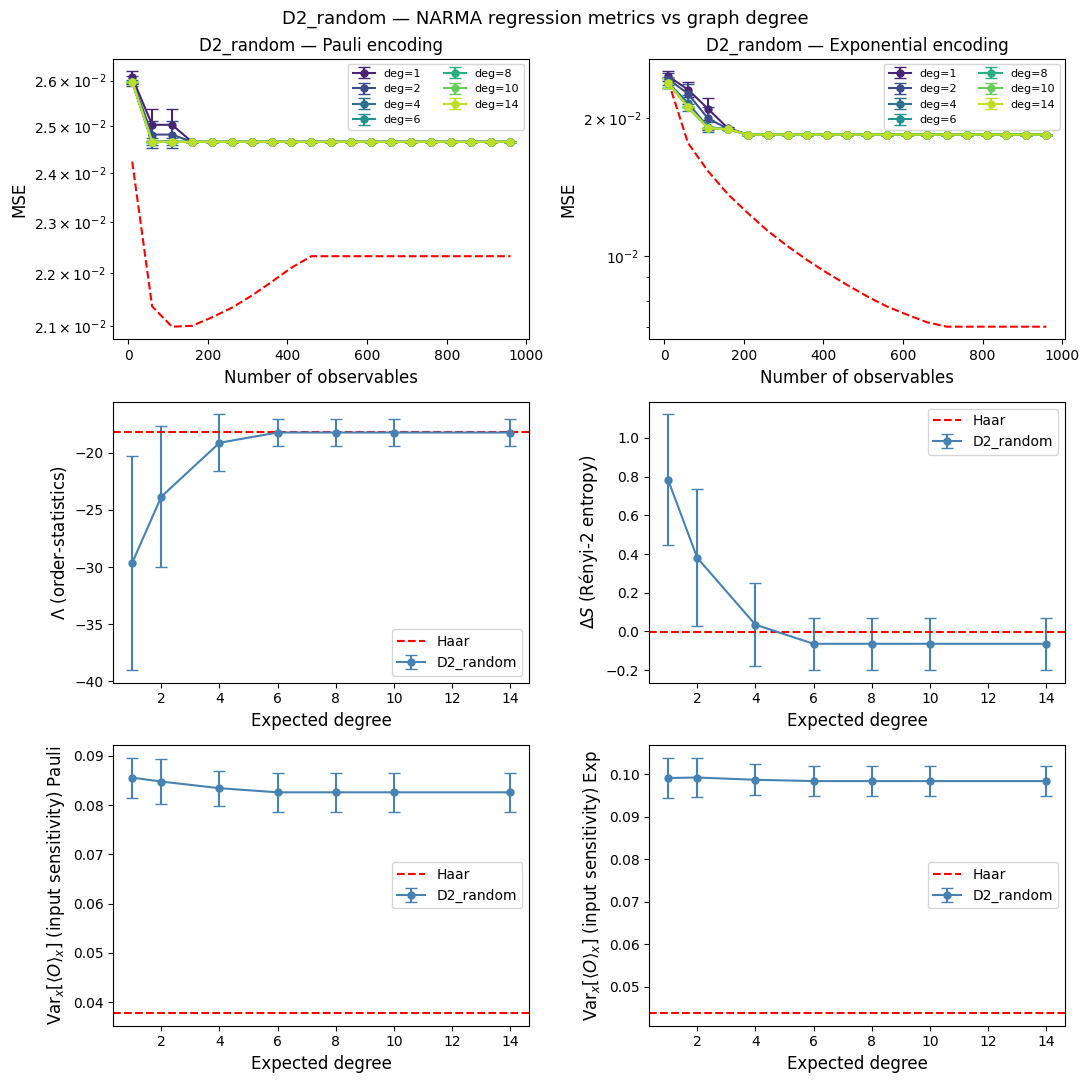

In [24]:
# ── D2_random: MSE curves + scalar metrics vs degree ────────────────────────────
cmap_d2 = plt.cm.viridis
colors_d2 = [cmap_d2(v) for v in np.linspace(0.1, 0.9, len(degrees))]
haar_m_p, haar_s_p = results_Haar['mse_p'].mean(axis=0), results_Haar['mse_p'].std(axis=0)
haar_m_e, haar_s_e = results_Haar['mse_e'].mean(axis=0), results_Haar['mse_e'].std(axis=0)
fig, axes = plt.subplots(3, 2, figsize=(11,11))

# Top row: MSE vs n_obs for Pauli and Exponential
for col, (enc_key, enc_label, haar_m, haar_s) in enumerate([
    ('mse_p', 'Pauli encoding', haar_m_p, haar_s_p),
    ('mse_e',   'Exponential encoding', haar_m_e, haar_s_e),
]):
    ax = axes[0, col]
    for deg, color in zip(degrees, colors_d2):
        m, s = results_degree[deg][enc_key].mean(axis=0),results_degree[deg][enc_key].std(axis=0)
        ax.errorbar(n_obs_list, m, yerr = s, color=color, fmt='o-',  capsize=4, ms=5, lw=1.5, label=f'deg={deg}')
        #ax.fill_between(n_obs_list, m - s, m + s, alpha=0.15, color=color)
    
    #ax.fill_between(n_obs_list, haar_m - haar_s, haar_m + haar_s, alpha=0.12, color='red')
    ax.set_xlabel('Number of observables', fontsize=12)
    ax.set_ylabel('MSE', fontsize=12)
    ax.set_title(f'D2_random — {enc_label}', fontsize=12)
    ax.legend(fontsize=8, ncol=2)
    ax.set_yscale('log')
axes[0, 0].plot(n_obs_list, haar_m_p, 'r--', lw=1.5, label='Haar')
axes[0, 1].plot(n_obs_list, haar_m_e, 'r--', lw=1.5, label='Haar')

# Hide unused top-right panel
#axes[0, 2].set_visible(False)

# Bottom row: scalar complexity metrics vs degree
haar_scalars = _sine_scalar(results_Haar)
for col, (key, label) in enumerate(METRIC_LABELS_SINE):
    ax = axes[1, col] if col < 2 else axes[2, col - 2]
    means = np.array([_sine_scalar(results_degree[d])[key].mean() for d in degrees])
    stds  = np.array([_sine_scalar(results_degree[d])[key].std()  for d in degrees])
    ax.errorbar(degrees, means, yerr=stds, fmt='o-', color='steelblue',
                capsize=4, lw=1.5, ms=5, label='D2_random')
    ax.axhline(haar_scalars[key].mean(), color='red', lw=1.5, ls='--', label='Haar')
    ax.set_xlabel('Expected degree', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.legend(fontsize=10)

fig.suptitle('D2_random — NARMA regression metrics vs graph degree', fontsize=13)
plt.tight_layout()
plt.show()

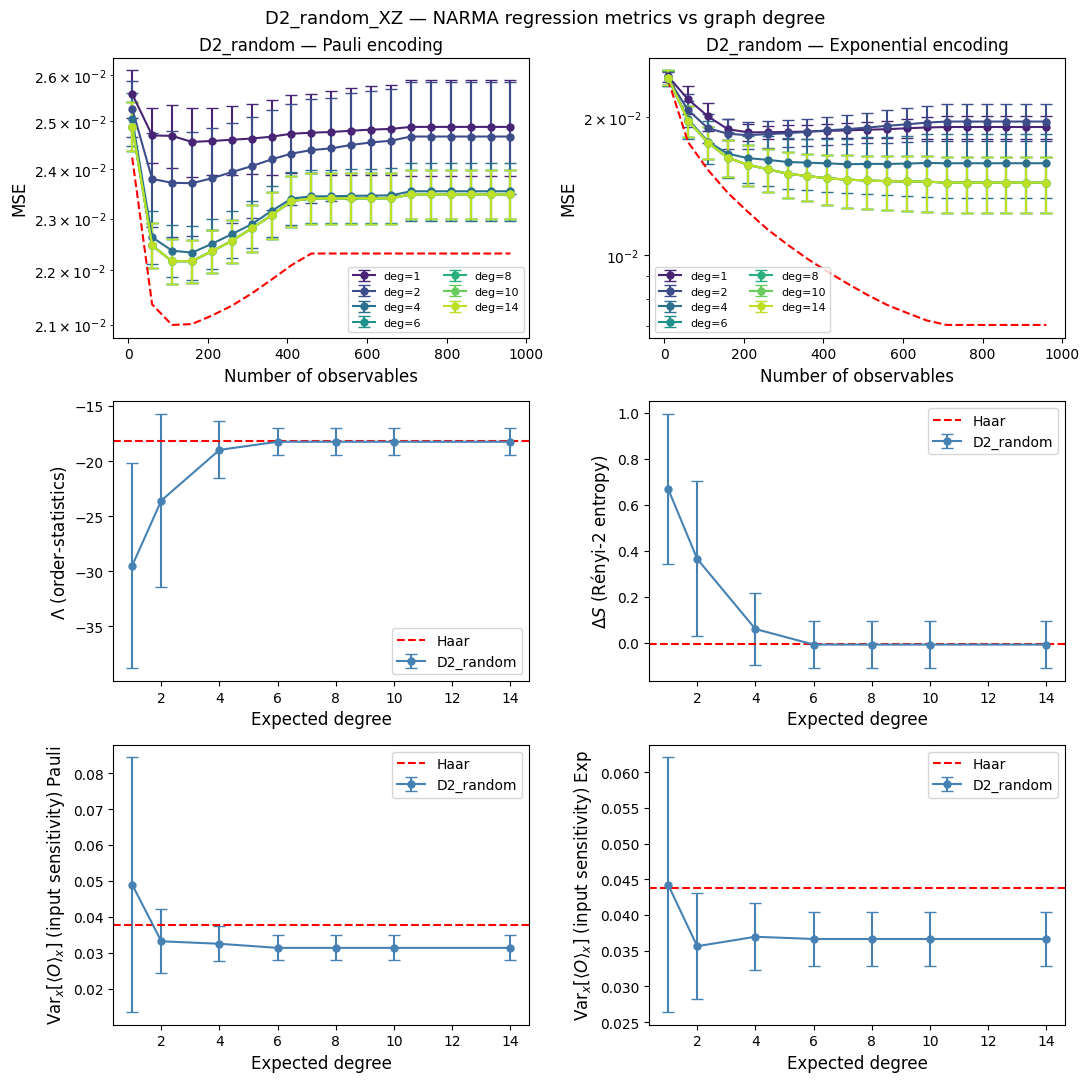

In [25]:
# ── D2_random_XZ: MSE curves + scalar metrics vs degree ────────────────────────────
cmap_d2 = plt.cm.viridis
colors_d2 = [cmap_d2(v) for v in np.linspace(0.1, 0.9, len(degrees))]
haar_m_p, haar_s_p = results_Haar['mse_p'].mean(axis=0), results_Haar['mse_p'].std(axis=0)
haar_m_e, haar_s_e = results_Haar['mse_e'].mean(axis=0), results_Haar['mse_e'].std(axis=0)
fig, axes = plt.subplots(3, 2, figsize=(11,11))

# Top row: MSE vs n_obs for Pauli and Exponential
for col, (enc_key, enc_label, haar_m, haar_s) in enumerate([
    ('mse_p', 'Pauli encoding', haar_m_p, haar_s_p),
    ('mse_e',   'Exponential encoding', haar_m_e, haar_s_e),
]):
    ax = axes[0, col]
    for deg, color in zip(degrees, colors_d2):
        m, s = results_degreeXZ[deg][enc_key].mean(axis=0),results_degreeXZ[deg][enc_key].std(axis=0)
        ax.errorbar(n_obs_list, m, yerr = s, color=color, fmt='o-',  capsize=4, ms=5, lw=1.5, label=f'deg={deg}')
        #ax.fill_between(n_obs_list, m - s, m + s, alpha=0.15, color=color)
    
    #ax.fill_between(n_obs_list, haar_m - haar_s, haar_m + haar_s, alpha=0.12, color='red')
    ax.set_xlabel('Number of observables', fontsize=12)
    ax.set_ylabel('MSE', fontsize=12)
    ax.set_title(f'D2_random — {enc_label}', fontsize=12)
    ax.legend(fontsize=8, ncol=2)
    ax.set_yscale('log')
axes[0, 0].plot(n_obs_list, haar_m_p, 'r--', lw=1.5, label='Haar')
axes[0, 1].plot(n_obs_list, haar_m_e, 'r--', lw=1.5, label='Haar')

# Hide unused top-right panel
#axes[0, 2].set_visible(False)

# Bottom row: scalar complexity metrics vs degree
haar_scalars = _sine_scalar(results_Haar)
for col, (key, label) in enumerate(METRIC_LABELS_SINE):
    ax = axes[1, col] if col < 2 else axes[2, col - 2]
    means = np.array([_sine_scalar(results_degreeXZ[d])[key].mean() for d in degrees])
    stds  = np.array([_sine_scalar(results_degreeXZ[d])[key].std()  for d in degrees])
    ax.errorbar(degrees, means, yerr=stds, fmt='o-', color='steelblue',
                capsize=4, lw=1.5, ms=5, label='D2_random')
    ax.axhline(haar_scalars[key].mean(), color='red', lw=1.5, ls='--', label='Haar')
    ax.set_xlabel('Expected degree', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.legend(fontsize=10)

fig.suptitle('D2_random_XZ — NARMA regression metrics vs graph degree', fontsize=13)
plt.tight_layout()
plt.show()

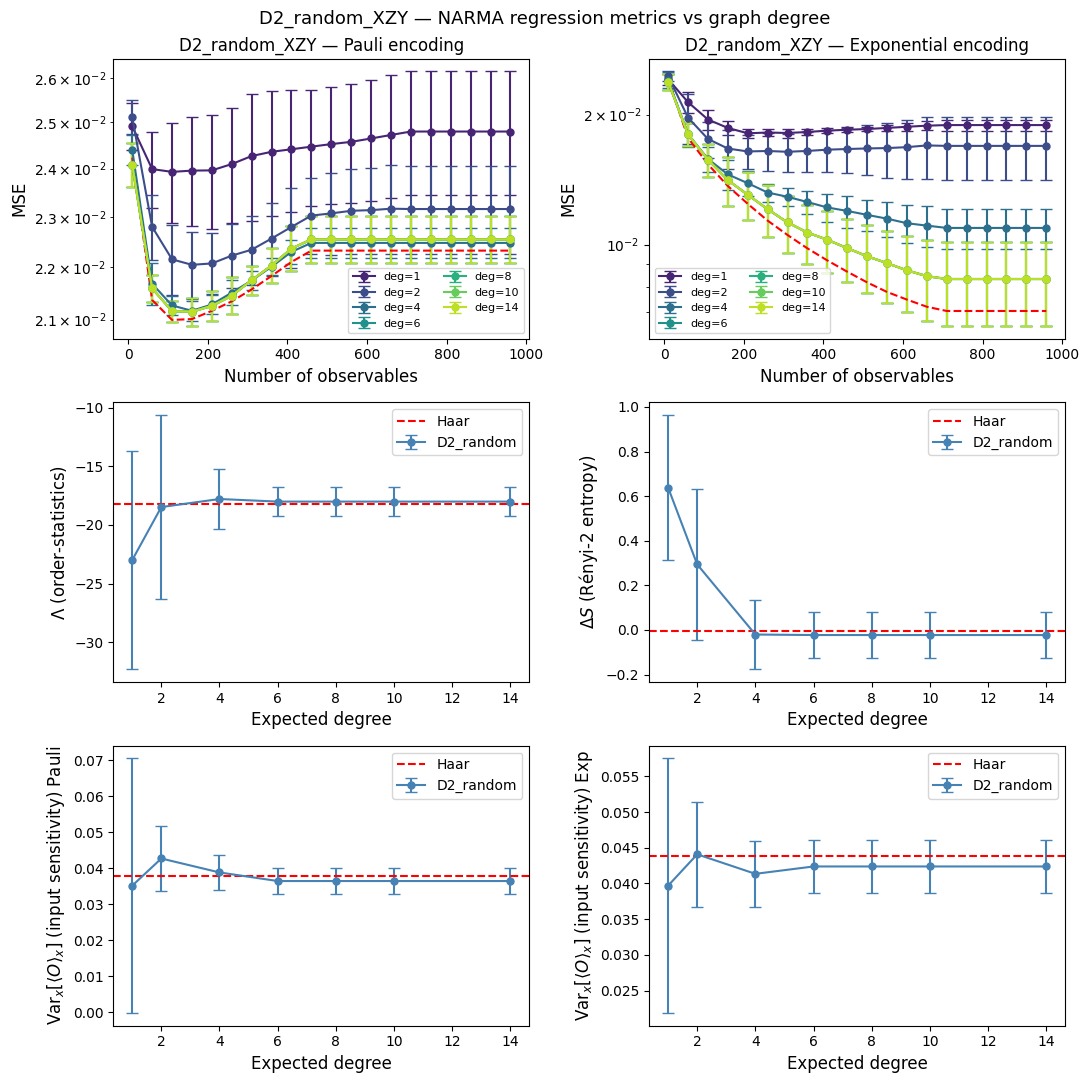

In [26]:
# ── D2_random_XZ: MSE curves + scalar metrics vs degree ────────────────────────────
cmap_d2 = plt.cm.viridis
colors_d2 = [cmap_d2(v) for v in np.linspace(0.1, 0.9, len(degrees))]
haar_m_p, haar_s_p = results_Haar['mse_p'].mean(axis=0), results_Haar['mse_p'].std(axis=0)
haar_m_e, haar_s_e = results_Haar['mse_e'].mean(axis=0), results_Haar['mse_e'].std(axis=0)
fig, axes = plt.subplots(3, 2, figsize=(11,11))

# Top row: MSE vs n_obs for Pauli and Exponential
for col, (enc_key, enc_label, haar_m, haar_s) in enumerate([
    ('mse_p', 'Pauli encoding', haar_m_p, haar_s_p),
    ('mse_e',   'Exponential encoding', haar_m_e, haar_s_e),
]):
    ax = axes[0, col]
    for deg, color in zip(degrees, colors_d2):
        m, s = results_degreeXZY[deg][enc_key].mean(axis=0),results_degreeXZY[deg][enc_key].std(axis=0)
        ax.errorbar(n_obs_list, m, yerr = s, color=color, fmt='o-',  capsize=4, ms=5, lw=1.5, label=f'deg={deg}')
        #ax.fill_between(n_obs_list, m - s, m + s, alpha=0.15, color=color)
    
    #ax.fill_between(n_obs_list, haar_m - haar_s, haar_m + haar_s, alpha=0.12, color='red')
    ax.set_xlabel('Number of observables', fontsize=12)
    ax.set_ylabel('MSE', fontsize=12)
    ax.set_title(f'D2_random_XZY — {enc_label}', fontsize=12)
    ax.legend(fontsize=8, ncol=2)
    ax.set_yscale('log')
axes[0, 0].plot(n_obs_list, haar_m_p, 'r--', lw=1.5, label='Haar')
axes[0, 1].plot(n_obs_list, haar_m_e, 'r--', lw=1.5, label='Haar')

# Hide unused top-right panel
#axes[0, 2].set_visible(False)

# Bottom row: scalar complexity metrics vs degree
haar_scalars = _sine_scalar(results_Haar)
for col, (key, label) in enumerate(METRIC_LABELS_SINE):
    ax = axes[1, col] if col < 2 else axes[2, col - 2]
    means = np.array([_sine_scalar(results_degreeXZY[d])[key].mean() for d in degrees])
    stds  = np.array([_sine_scalar(results_degreeXZ[d])[key].std()  for d in degrees])
    ax.errorbar(degrees, means, yerr=stds, fmt='o-', color='steelblue',
                capsize=4, lw=1.5, ms=5, label='D2_random')
    ax.axhline(haar_scalars[key].mean(), color='red', lw=1.5, ls='--', label='Haar')
    ax.set_xlabel('Expected degree', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.legend(fontsize=10)

fig.suptitle('D2_random_XZY — NARMA regression metrics vs graph degree', fontsize=13)
plt.tight_layout()
plt.show()

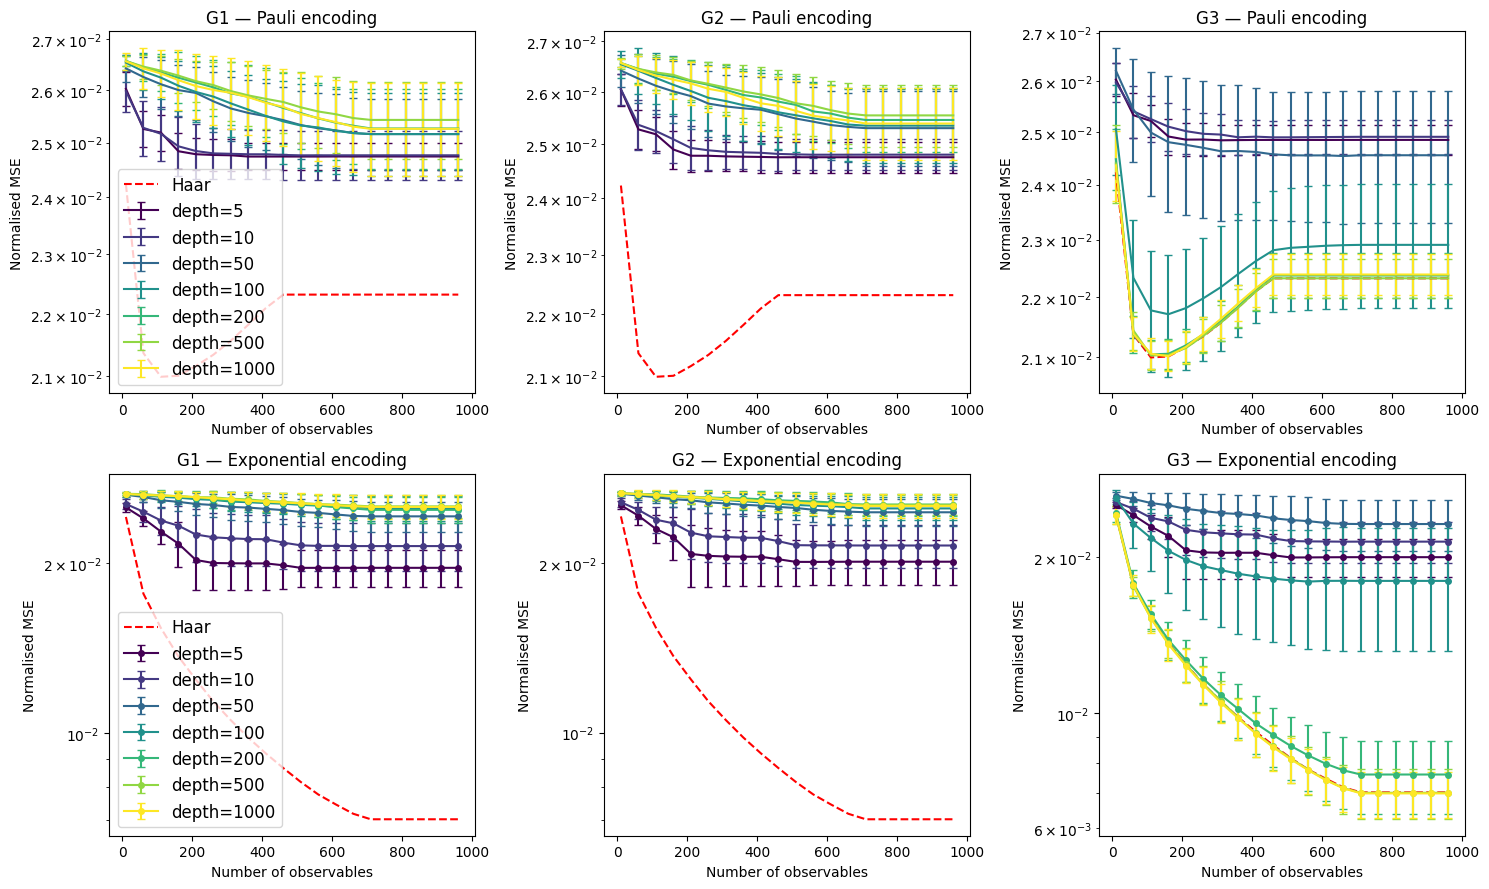

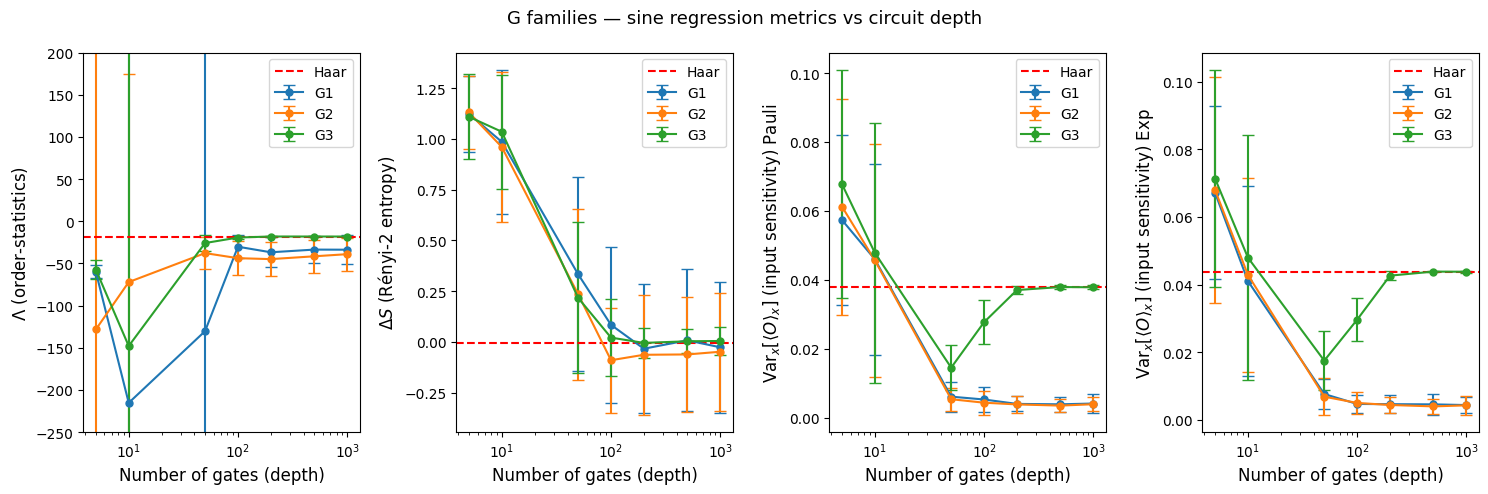

In [27]:
# ── G1/G2/G3: MSE curves + scalar metrics vs depth ──────────────────────────────
colors_g = {"G1": "tab:blue", "G2": "tab:orange", "G3": "tab:green"}
haar_m_p, haar_s_p = results_Haar['mse_p'].mean(axis=0), results_Haar['mse_p'].std(axis=0)
haar_m_e, haar_s_e = results_Haar['mse_e'].mean(axis=0), results_Haar['mse_e'].std(axis=0)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

cmap_depth = plt.cm.viridis
depth_colors = {d: cmap_depth(i / (len(g_depths) - 1)) 
                for i, d in enumerate(g_depths)}

# Top: Pauli encoding, one column per family
for col, family in enumerate(g_families):
    ax = axes[0, col]
    for depth in g_depths:
        m = results_g[family][depth]['mse_p'].mean(axis=0)
        s = results_g[family][depth]['mse_p'].std(axis=0)
        ax.errorbar(n_obs_list, m, yerr=s, color=depth_colors[depth],
                    capsize=3, lw=1.5, ms=4, label=f'depth={depth}')
    ax.plot(n_obs_list, haar_m_p, 'r--', lw=1.5, label='Haar')
    ax.set_xlabel('Number of observables')
    ax.set_ylabel('Normalised MSE')
    ax.set_title(f'{family} — Pauli encoding')
    ax.set_yscale('log')
    if col == 0:
        ax.legend(fontsize=12, loc='best')

# Bottom: Exponential encoding, one column per family
for col, family in enumerate(g_families):
    ax = axes[1, col]
    for depth in g_depths:
        m = results_g[family][depth]['mse_e'].mean(axis=0)
        s = results_g[family][depth]['mse_e'].std(axis=0)
        ax.errorbar(n_obs_list, m, yerr=s, color=depth_colors[depth],
                    fmt='o-', capsize=3, lw=1.5, ms=4, label=f'depth={depth}')
    ax.plot(n_obs_list, haar_m_e, 'r--', lw=1.5, label='Haar')
    ax.set_xlabel('Number of observables')
    ax.set_ylabel('Normalised MSE')
    ax.set_title(f'{family} — Exponential encoding')
    ax.set_yscale('log')
    if col == 0:
        ax.legend(fontsize=12, loc='best')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

# Bottom row: scalar complexity metrics vs depth
haar_scalars = _sine_scalar(results_Haar)
for col, (key, label) in enumerate(METRIC_LABELS_SINE):
    ax = axes[col]
    for family in g_families:
        means = np.array([_sine_scalar(results_g[family][d])[key].mean()
                          for d in g_depths])
        stds  = np.array([_sine_scalar(results_g[family][d])[key].std()
                          for d in g_depths])
        ax.errorbar(g_depths, means, yerr=stds, fmt='o-',
                    color=colors_g[family], capsize=4, lw=1.5, ms=5, label=family)
    ax.axhline(haar_scalars[key].mean(), color='red', lw=1.5, ls='--', label='Haar')
    ax.set_xscale('log')
    ax.set_xlabel('Number of gates (depth)', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.legend(fontsize=10)
axes[0].set_ylim(-250,200)
fig.suptitle('G families — sine regression metrics vs circuit depth', fontsize=13)
plt.tight_layout()
plt.show()

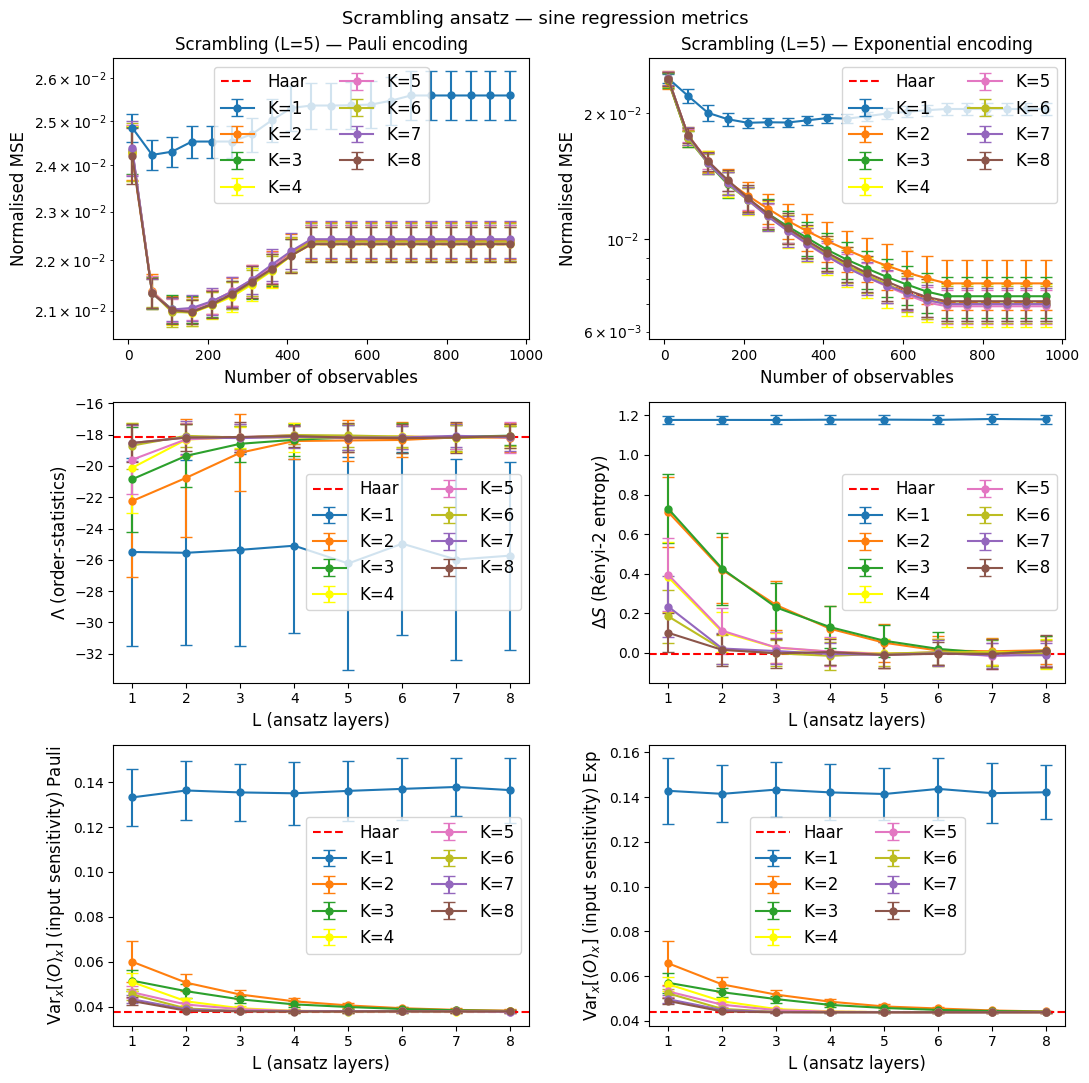

In [28]:
# ── Scrambling ansatz: MSE curves + scalar metrics (L on x-axis, K as colour) ─────
cmap_K = plt.cm.cool
colors_K = {1: "tab:blue", 2: "tab:orange", 3: "tab:green", 4:"yellow",  5: "tab:pink", 6: "tab:olive", 7: "tab:purple", 8: "tab:brown"}
haar_m_p, haar_s_p = results_Haar['mse_p'].mean(axis=0), results_Haar['mse_p'].std(axis=0)
haar_m_e, haar_s_e = results_Haar['mse_e'].mean(axis=0), results_Haar['mse_e'].std(axis=0)

fig, axes = plt.subplots(3, 2, figsize=(11,11))

# Top row: MSE vs n_obs for the largest L (L_sine[-1]) and all K values
L_ref = 5#L_sine[-1]   # show the deepest L for clarity
for col, (enc_key, enc_label, haar_m, haar_s) in enumerate([
    ('mse_p', 'Pauli encoding', haar_m_p, haar_s_p),
    ('mse_e',   'Exponential encoding', haar_m_e, haar_s_e),
]):
    ax = axes[0, col]
    for K_val in K_values:
        m, s = results_scrambling[(L_ref, K_val)][enc_key].mean(axis=0), results_scrambling[(L_ref, K_val)][enc_key].std(axis=0)#_mse_curve(results_sine_scrambling[(L_ref, K_val)], enc_key)
        ax.errorbar(n_obs_list, m, yerr=s, color=colors_K[K_val], fmt='o-', capsize=4, lw=1.5, ms=5, label=f'K={K_val}')
    ax.plot(n_obs_list, haar_m, 'r--', lw=1.5, label='Haar')
    ax.set_xlabel('Number of observables', fontsize=12)
    ax.set_ylabel('Normalised MSE', fontsize=12)
    ax.set_title(f'Scrambling (L={L_ref}) — {enc_label}', fontsize=12)
    ax.legend(fontsize=12, ncol=2)
    ax.set_yscale('log')


# Bottom row: scalar complexity metrics vs L (for all K)
haar_scalars = _sine_scalar(results_Haar)
for col, (key, label) in enumerate(METRIC_LABELS_SINE):
    ax = axes[1, col] if col < 2 else axes[2, col - 2]
    for K_val in K_values:
        means = np.array([_sine_scalar(results_scrambling[(L_v, K_val)])[key].mean()
                          for L_v in L_values])
        stds  = np.array([_sine_scalar(results_scrambling[(L_v, K_val)])[key].std()
                          for L_v in L_values])
        ax.errorbar(L_values, means, yerr=stds, fmt='o-',
                    color=colors_K[K_val], capsize=4, lw=1.5, ms=5, label=f'K={K_val}')
    ax.axhline(haar_scalars[key].mean(), color='red', lw=1.5, ls='--', label='Haar')
    ax.set_xlabel('L (ansatz layers)', fontsize=12)
    ax.set_ylabel(label, fontsize=12)
    ax.legend(fontsize=12, ncol=2)

fig.suptitle('Scrambling ansatz — sine regression metrics', fontsize=13)
plt.tight_layout()
plt.show()


## Joint Plot — MSE vs Effective Rank

The main diagnostic figure: MSE (y-axis) vs \(R_{\mathrm{eff}}\) (x-axis), with colour encoding \(\Lambda\).

This plot directly tests the central hypothesis: if \(R_{\mathrm{eff}}\) is the binding constraint, all families should fall on a common curve regardless of their gate structure. Families with low \(\Lambda\) but high \(R_{\mathrm{eff}}\) (if any) would reveal exceptions where expressivity and feature coverage decouple.

In [29]:
# ─────────────────────────────────────────────────────────────────────
# CELL A — R_eff helper and post-hoc augmentation
# ─────────────────────────────────────────────────────────────────────
def effective_rank(F, eps=1e-12):
    """Participation ratio of singular values of the centred feature matrix."""
    F = F - F.mean(axis=0, keepdims=True)
    try:
        sv = np.linalg.svd(F, compute_uv=False)
    except np.linalg.LinAlgError:
        from scipy.linalg import svd
        sv = svd(F, compute_uv=False, lapack_driver='gesvd')
    sv = sv[sv > eps]
    if len(sv) == 0:
        return 0.0
    return float(sv.sum() ** 2 / (sv ** 2).sum())
 
 
def add_R_eff(res):
    """
    Compute R_eff from the saved last-run feature matrix and attach to the
    result dict. Returns the (mutated) dict for convenience.
    """
    if 'R_eff_e' in res:
        return res  # already done
    X = np.asarray(res['X_train_e'])
    res['R_eff_e'] = effective_rank(X)
    return res
 
 
# Augment all loaded result dicts
add_R_eff(results_Haar)
 
for family in g_families:
    for depth in results_g[family]:
        add_R_eff(results_g[family][depth])
 
for deg in results_degree:
    add_R_eff(results_degree[deg])
 
# When D2_random_XZ is available, add the same for it:
# results_degree_xz = {...}    # from your D2_random_XZ sweep cell
for deg in results_degreeXZ:
    add_R_eff(results_degreeXZ[deg])

for deg in results_degreeXZY:
    add_R_eff(results_degreeXZY[deg])
 
print(f"Haar R_eff = {results_Haar['R_eff_e']:.1f}")
for family in g_families:
    rs = [results_g[family][d]['R_eff_e'] for d in g_depths]
    print(f"{family}: R_eff (depths {g_depths}): {[f'{r:.0f}' for r in rs]}")
rs = [results_degree[d]['R_eff_e'] for d in degrees]
print(f"D2_random: R_eff (degrees {degrees}): {[f'{r:.0f}' for r in rs]}")
rs = [results_degreeXZ[d]['R_eff_e'] for d in degrees]
print(f"D2_random_XZ: R_eff (degrees {degrees}): {[f'{r:.0f}' for r in rs]}")
rs = [results_degreeXZY[d]['R_eff_e'] for d in degrees]
print(f"D2_random_XZY: R_eff (degrees {degrees}): {[f'{r:.0f}' for r in rs]}") 

Haar R_eff = 142.3
G1: R_eff (depths [5, 10, 50, 100, 200, 500, 1000]): ['18', '13', '13', '3', '7', '7', '4']
G2: R_eff (depths [5, 10, 50, 100, 200, 500, 1000]): ['13', '73', '11', '5', '6', '5', '12']
G3: R_eff (depths [5, 10, 50, 100, 200, 500, 1000]): ['16', '13', '10', '125', '145', '143', '146']
D2_random: R_eff (degrees [1, 2, 4, 6, 8, 10, 14]): ['20', '20', '20', '20', '20', '20', '20']
D2_random_XZ: R_eff (degrees [1, 2, 4, 6, 8, 10, 14]): ['28', '28', '36', '63', '63', '63', '63']
D2_random_XZY: R_eff (degrees [1, 2, 4, 6, 8, 10, 14]): ['88', '31', '93', '122', '122', '122', '122']


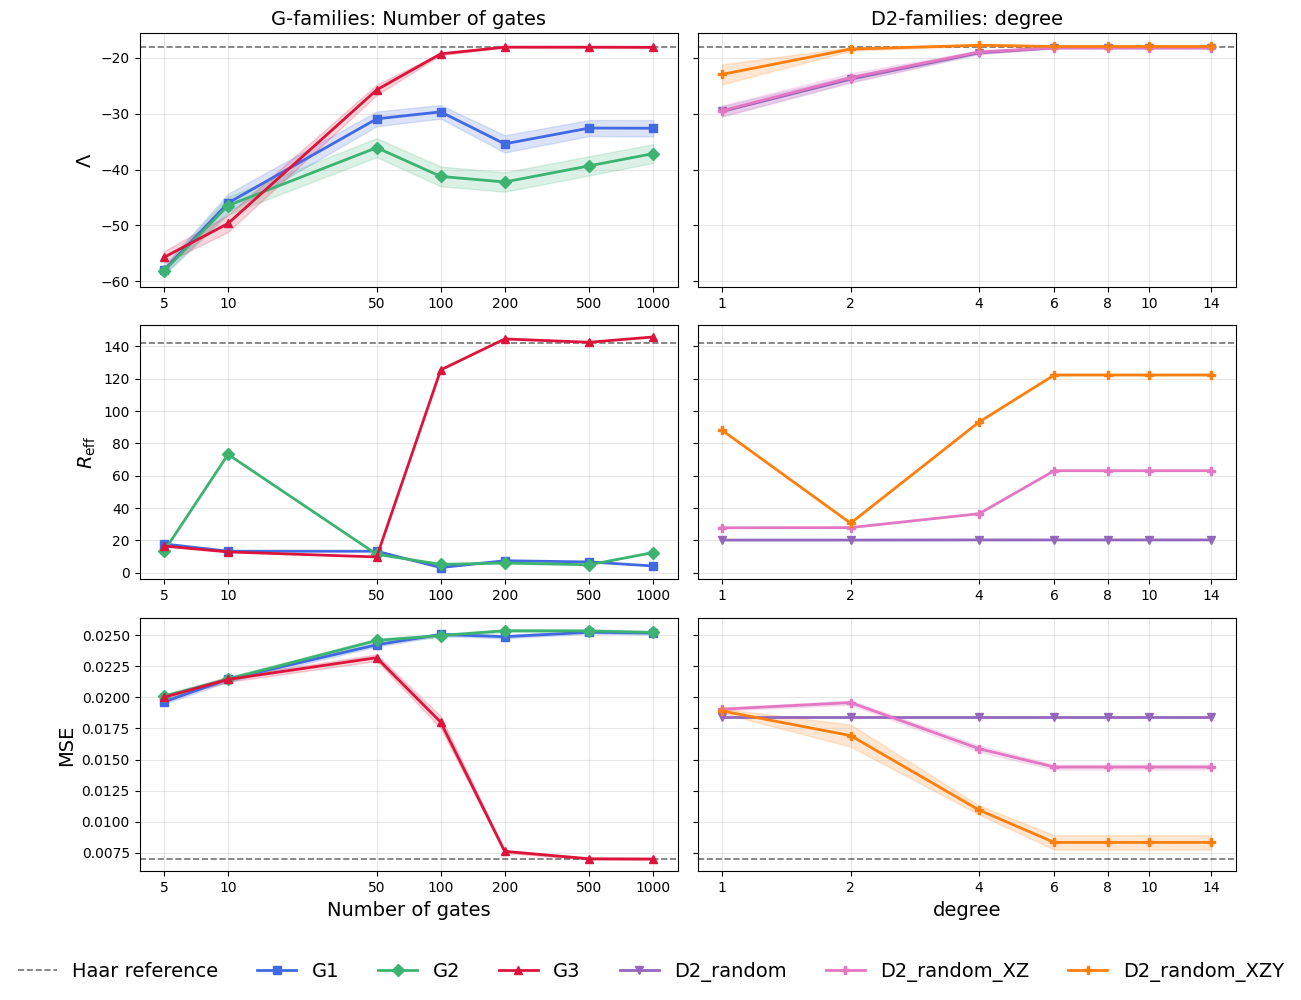

In [30]:
from matplotlib.ticker import ScalarFormatter, NullLocator

# ─────────────────────────────────────────────────────────────────────
# Style — matches QELM Figure 2
# ─────────────────────────────────────────────────────────────────────
FAMILY_COLORS = {
    'Haar':           '#000000',
    'G1':             'royalblue',
    'G2':             'mediumseagreen',
    'G3':             'crimson',
    'D2_random':      '#9467bd',
    'D2_random_XZ':   '#e377c2',
    'D2_random_XZY':   'tab:orange',
}
FAMILY_MARKERS = {
    'Haar': 'o', 'G1': 's', 'G2': 'D', 'G3': '^',
    'D2_random': 'v', 'D2_random_XZ': 'P', 'D2_random_XZY': 'P',
}

ORS_LOWER_CAP = -60.0
MSE_FLOOR     = 1e-15


# ─────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────
def _scalar_stats(res, key, clip_low=None):
    """Mean and SEM of a (ns,) array; clipped if requested. Returns NaN, NaN if missing."""
    if key not in res:
        return np.nan, np.nan
    vals = np.asarray(res[key])
    if vals.ndim == 2:
        vals = vals[:, -1]   # full pool = last n_obs index
    if clip_low is not None:
        vals = np.clip(vals, clip_low, None)
    ns = len(vals)
    return float(np.mean(vals)), float(np.std(vals) / np.sqrt(ns)) if ns > 1 else 0.0


def _haar_scalar(metric_key, clip_low=None):
    if metric_key == 'R_eff_e':
        return results_Haar['R_eff_e']
    m, _ = _scalar_stats(results_Haar, metric_key, clip_low=clip_low)
    return m


def _collect_G(family):
    depths = sorted(results_g[family].keys())
    ors_m, ors_s, reff, mse_m, mse_s = [], [], [], [], []
    for d in depths:
        r = results_g[family][d]
        m, s = _scalar_stats(r, 'ors', clip_low=ORS_LOWER_CAP)
        ors_m.append(m); ors_s.append(s)
        reff.append(r['R_eff_e'])
        m, s = _scalar_stats(r, 'mse_e', clip_low=MSE_FLOOR)
        mse_m.append(m); mse_s.append(s)
    return (np.array(depths), np.array(ors_m), np.array(ors_s),
            np.array(reff), np.array(mse_m), np.array(mse_s))


def _collect_D2(results_dict):
    degs = sorted(results_dict.keys())
    ors_m, ors_s, reff, mse_m, mse_s = [], [], [], [], []
    for d in degs:
        r = results_dict[d]
        m, s = _scalar_stats(r, 'ors', clip_low=ORS_LOWER_CAP)
        ors_m.append(m); ors_s.append(s)
        reff.append(r['R_eff_e'])
        m, s = _scalar_stats(r, 'mse_e', clip_low=MSE_FLOOR)
        mse_m.append(m); mse_s.append(s)
    return (np.array(degs), np.array(ors_m), np.array(ors_s),
            np.array(reff), np.array(mse_m), np.array(mse_s))


# ─────────────────────────────────────────────────────────────────────
# Figure
# ─────────────────────────────────────────────────────────────────────
def fig2_narma(save_path=None,
               ors_cap=ORS_LOWER_CAP, mse_floor=MSE_FLOOR):
    if save_path is None:
        save_path = f'fig2_narma_n{nqbits}.png'

    fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey='row')

    # Pre-collect family data
    g_target = ['G1', 'G2', 'G3']
    g_data = {fam: _collect_G(fam) for fam in g_target}
    d2_data = {'D2_random': _collect_D2(results_degree)}
    d2_data['D2_random_XZ'] = _collect_D2(globals()['results_degreeXZ'])
    d2_data['D2_random_XZY'] = _collect_D2(globals()['results_degreeXZY'])
    metrics = [
        ('ors',     r'$\Lambda$'),
        ('R_eff_e', r'$R_{\rm eff}$'),
        ('mse_e',   'MSE'),
    ]

    for row, (key, ylabel) in enumerate(metrics):
        for col in range(2):
            ax = axes[row, col]

            # Haar horizontal reference
            clip_low = ors_cap if key == 'ors' else (mse_floor if key == 'mse_e' else None)
            href = _haar_scalar(key, clip_low=clip_low)
            if href is not None and not np.isnan(href):
                ax.axhline(href, color=FAMILY_COLORS['Haar'],
                           ls='--', alpha=0.55, lw=1.2,
                           label='Haar reference' if (row == 0 and col == 0) else None)

            # Plot per family
            if col == 0:
                families = g_target
                data_src = g_data
            else:
                families = list(d2_data.keys())
                data_src = d2_data

            cs_max = None
            for family in families:
                color = FAMILY_COLORS.get(family, '#888')
                marker = FAMILY_MARKERS.get(family, 'o')
                cs, ors_m, ors_s, reff, mse_m, mse_s = data_src[family]
                if len(cs) == 0:
                    continue
                cs_max = cs  # remember last for tick labels

                if key == 'ors':
                    ax.plot(cs, ors_m, marker=marker, color=color, lw=2.0,
                            label=family if row == 0 else None)
                    ax.fill_between(cs, ors_m - ors_s, ors_m + ors_s,
                                    color=color, alpha=0.18)
                elif key == 'R_eff_e':
                    ax.plot(cs, reff, marker=marker, color=color, lw=2.0,
                            label=family if row == 0 else None)
                else:  # mse_e
                    ax.plot(cs, mse_m, marker=marker, color=color, lw=2.0,
                            label=family if row == 0 else None)
                    ax.fill_between(cs, mse_m - mse_s, mse_m + mse_s,
                                    color=color, alpha=0.18)

            # Scales
            ax.set_xscale('log')
            ax.grid(True, which='both', alpha=0.3)

            # Numeric tick labels on x-axis (no scientific notation)
            if cs_max is not None:
                ax.set_xticks(cs_max)
                ax.get_xaxis().set_major_formatter(ScalarFormatter())
                ax.get_xaxis().set_minor_locator(NullLocator())

            # Titles, labels
            if row == 0:
                ax.set_title('G-families: Number of gates' if col == 0
                             else 'D2-families: degree', fontsize=14)
            if row == 2:
                ax.set_xlabel('Number of gates' if col == 0 else 'degree',
                              fontsize=14)
            if col == 0:
                ax.set_ylabel(ylabel, fontsize=14)

    # Single legend at the bottom
    handles, labels = [], []
    for ax in axes[0]:
        h, l = ax.get_legend_handles_labels()
        for hh, ll in zip(h, l):
            if ll not in labels:
                handles.append(hh)
                labels.append(ll)
    fig.legend(handles, labels, loc='upper center',
               bbox_to_anchor=(0.5, -0.01), ncol=len(labels),
               fontsize=14, frameon=False)

    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(save_path, dpi=160, bbox_inches='tight')
    plt.show()


# Call it
fig2_narma()